In [20]:
# 課題2
"""
自分の興味のあるデータ（対象は何でも良いが回帰の問題をおすすめする：SHAPバージョンによるトラブルを避けるため）について
今回と同様のRandomForestやSHAP値による解析を行い，対象のデータの予測に効く変数がどのようなものか，
またそこからどのようなことが考察できるのか（どのような現象が発生しているか？など）について考察を行え
"""

'\n自分の興味のあるデータ（対象は何でも良いが回帰の問題をおすすめする：SHAPバージョンによるトラブルを避けるため）について\n今回と同様のRandomForestやSHAP値による解析を行い，対象のデータの予測に効く変数がどのようなものか，\nまたそこからどのようなことが考察できるのか（どのような現象が発生しているか？など）について考察を行え\n'

In [21]:
%pip install xgboost
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import shap

In [23]:
# データ準備
df = pd.read_csv('data/data.csv') 

target_col = 'Win'

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,144.0,2019.500000,3.464102,2014.000,2016.75000,2019.500,2022.25000,2025.000
Win,144.0,68.277778,9.963180,41.000,61.00000,68.000,74.00000,94.000
Lose,144.0,68.277778,9.959670,42.000,62.00000,69.000,76.00000,96.000
AVG,144.0,0.249764,0.010652,0.212,0.24300,0.249,0.25700,0.280
Game,144.0,141.166667,6.410219,120.000,143.00000,143.000,143.00000,144.000
turn_at_bat,144.0,5322.555556,266.664892,4437.000,5299.50000,5383.000,5453.25000,5663.000
AB,144.0,4709.645833,237.408134,3840.000,4709.50000,4775.000,4823.25000,5023.000
R,144.0,540.131944,77.372973,350.000,492.75000,536.000,586.00000,792.000
Hit,144.0,1176.854167,86.079892,902.000,1139.25000,1184.500,1229.25000,1401.000
2B,144.0,201.555556,22.384053,146.000,187.50000,203.500,216.25000,260.000


In [24]:
# 欠損値の確認
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 45 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         144 non-null    int64  
 1   League       144 non-null    object 
 2   Team         144 non-null    object 
 3   Win          144 non-null    int64  
 4   Lose         144 non-null    int64  
 5   AVG          144 non-null    float64
 6   Game         144 non-null    int64  
 7   turn_at_bat  144 non-null    int64  
 8   AB           144 non-null    int64  
 9   R            144 non-null    int64  
 10  Hit          144 non-null    int64  
 11  2B           144 non-null    int64  
 12  3B           144 non-null    int64  
 13  HR           144 non-null    int64  
 14  BH           144 non-null    int64  
 15  RBI          144 non-null    int64  
 16  SB           144 non-null    int64  
 17  CS           144 non-null    int64  
 18  SH           144 non-null    int64  
 19  SF      

In [25]:
# 不要な変数の削除
df = df.drop(["Year", "League", "Team", "Lose", "Game", "RBI", "SLG", "OBP", "HP", "IP", "ER", "R_P" ], axis=1)
df

,Win,AVG,turn_at_bat,AB,R,Hit,2B,3B,HR,BH,...,CP,BF,H_P,HR_P,BB_P,IW_P,HBP_P,K,WP,Balk
0,67,0.253,5464,4833,568,1224,211,27,121,1852,...,11,5582,1321,130,456,14,47,939,56,9
1,60,0.279,5653,5023,667,1401,223,15,139,2071,...,5,5645,1386,161,484,22,40,940,38,7
2,67,0.258,5521,4854,570,1250,215,21,87,1768,...,6,5505,1213,110,503,8,52,970,40,6
3,82,0.257,5480,4862,596,1248,207,7,144,1901,...,10,5510,1288,122,380,18,49,998,51,4
4,74,0.272,5538,4878,649,1326,219,23,153,2050,...,6,5478,1298,121,408,10,55,933,32,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,87,0.257,5399,4785,551,1229,186,29,101,1776,...,5,5194,1063,90,335,15,61,1124,16,0
140,56,0.241,5304,4790,441,1153,199,20,73,1611,...,4,5418,1185,116,437,9,57,1023,50,0
141,83,0.248,5396,4866,548,1209,195,31,129,1853,...,23,5253,1110,104,302,19,39,1052,24,3
142,67,0.244,5423,4824,446,1179,146,26,70,1587,...,3,5508,1266,99,438,14,55,977,27,2


In [26]:
# 説明変数(X)と目的変数(y)に分離
X = df.drop(target_col, axis=1)
y = df[target_col]

# 訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# SVM用に標準化（回帰でもSVMはスケールの影響を強く受けます）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns) # SHAP用

In [27]:
# モデル構築（回帰モデルに変更）

# XGBoost Regressor
xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, max_depth=10) # 深さは適宜調整
rf_model.fit(X_train, y_train)

# SVM Regressor (SVR)
# データ数が多いと時間がかかるため、多い場合は訓練データを間引く等の工夫が必要
svm_model = SVR(kernel='rbf') 
svm_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [28]:
# 評価（R2スコアやRMSEに変更）
models = {'XGBoost': xgb_model, 'Random Forest': rf_model}
preds = {}

# Tree系モデルの評価
for name, model in models.items():
    pred = model.predict(X_test)
    preds[name] = pred
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"[{name}] RMSE: {rmse:.4f}, R2: {r2:.4f}")

# SVMの評価
svm_pred = svm_model.predict(X_test_scaled)
rmse_svm = np.sqrt(mean_squared_error(y_test, svm_pred))
r2_svm = r2_score(y_test, svm_pred)
print(f"[SVM]     RMSE: {rmse_svm:.4f}, R2: {r2_svm:.4f}")

[XGBoost] RMSE: 5.4673, R2: 0.7144
[Random Forest] RMSE: 5.3462, R2: 0.7269
[SVM]     RMSE: 8.5729, R2: 0.2979


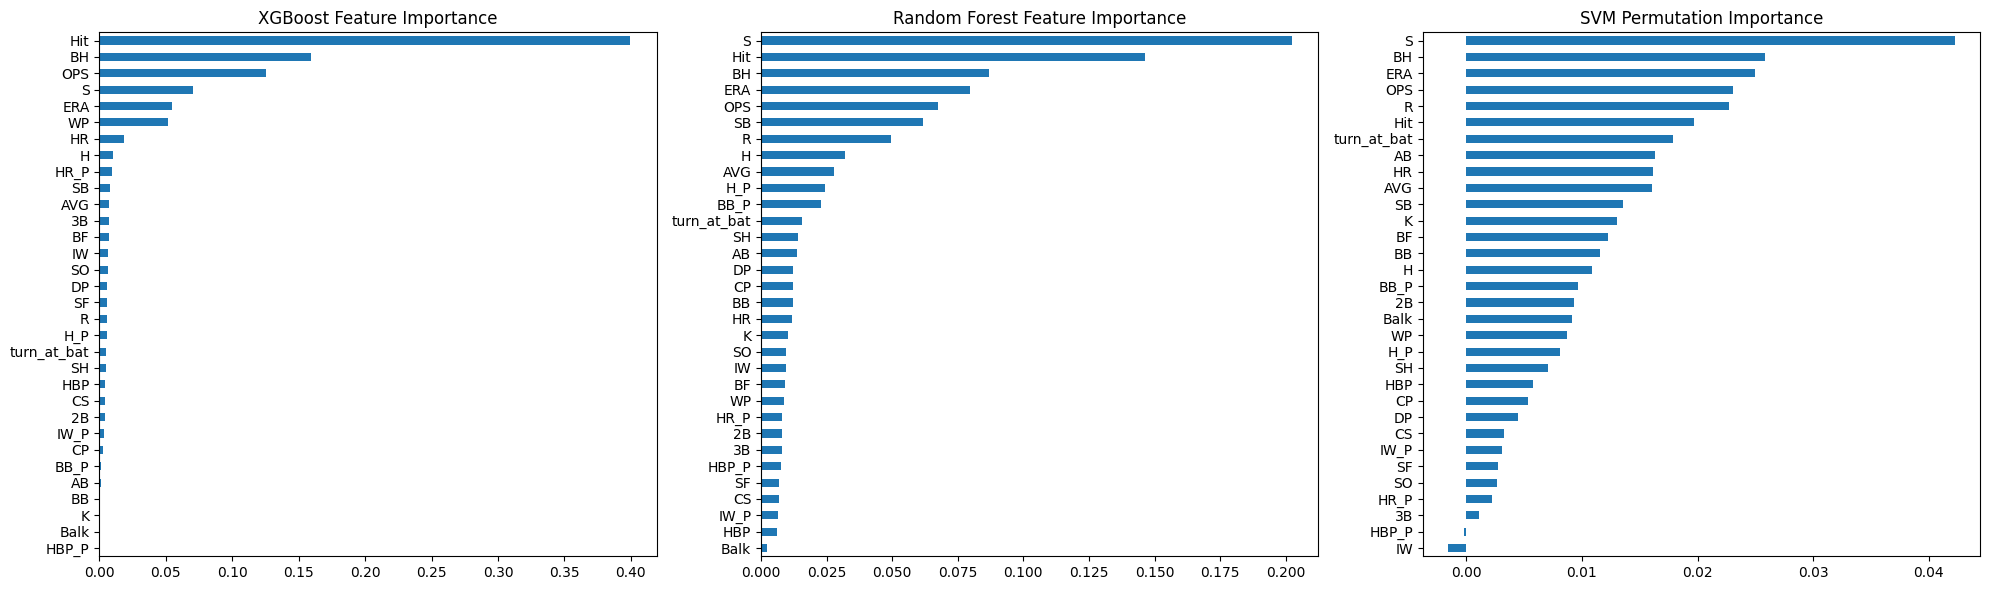

In [29]:
# 変数重要度の比較
# Gini重要度 (Random Forest & XGBoost)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# XGBoost
pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values().plot(
    kind='barh', ax=axes[0], title='XGBoost Feature Importance'
)

# Random Forest
pd.Series(rf_model.feature_importances_, index=X.columns).sort_values().plot(
    kind='barh', ax=axes[1], title='Random Forest Feature Importance'
)

# SVM (Permutation Importance)
# SVMは係数が見えないため、変数を入れ替えて精度低下を見る手法を使います
perm_importance = permutation_importance(svm_model, X_test_scaled, y_test, n_repeats=5, random_state=42)
pd.Series(perm_importance.importances_mean, index=X.columns).sort_values().plot(
    kind='barh', ax=axes[2], title='SVM Permutation Importance'
)
plt.tight_layout()
plt.show()

In [30]:
# SHAP値による解析
# XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Random Forest
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)

# SVM (KernelExplainer: 計算が重いため、データが多い場合はkmeansで要約するか、sample数を減らしてください)
# ここではテストデータの先頭100件だけで計算する例にします
X_test_sample = X_test_scaled_df.iloc[:100, :] 
# 背景データとして訓練データを要約
X_train_summary = shap.kmeans(X_train_scaled, 10) 
explainer_svm = shap.KernelExplainer(svm_model.predict, X_train_summary)
shap_values_svm = explainer_svm.shap_values(X_test_sample)

100%|██████████| 44/44 [00:06<00:00,  6.37it/s]


XGBoost SHAP


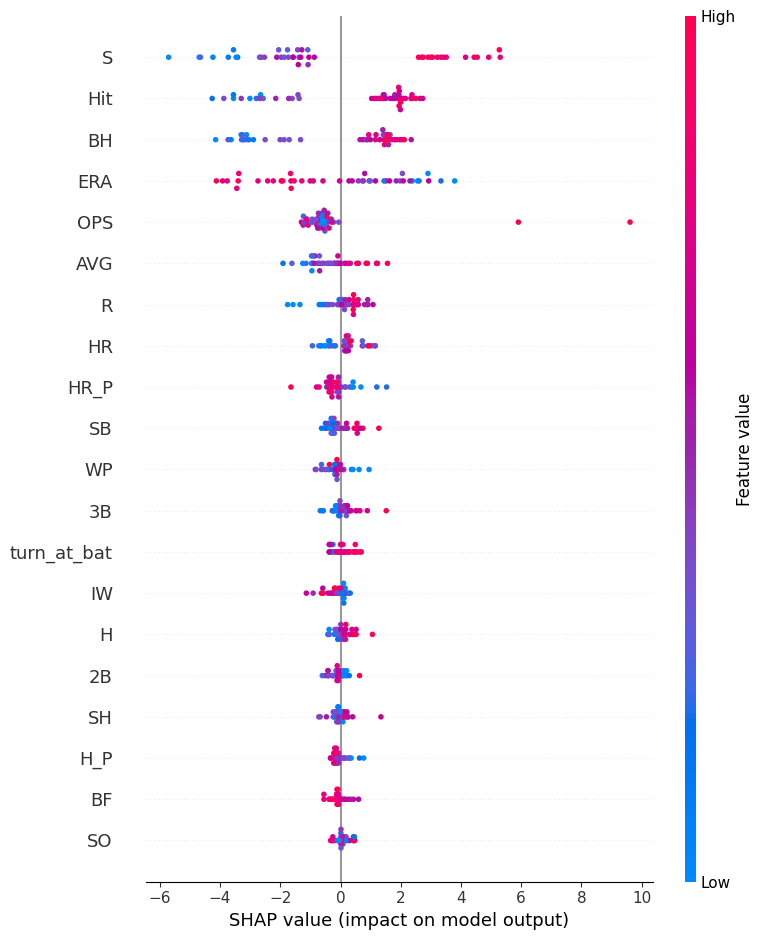

Random Forest SHAP


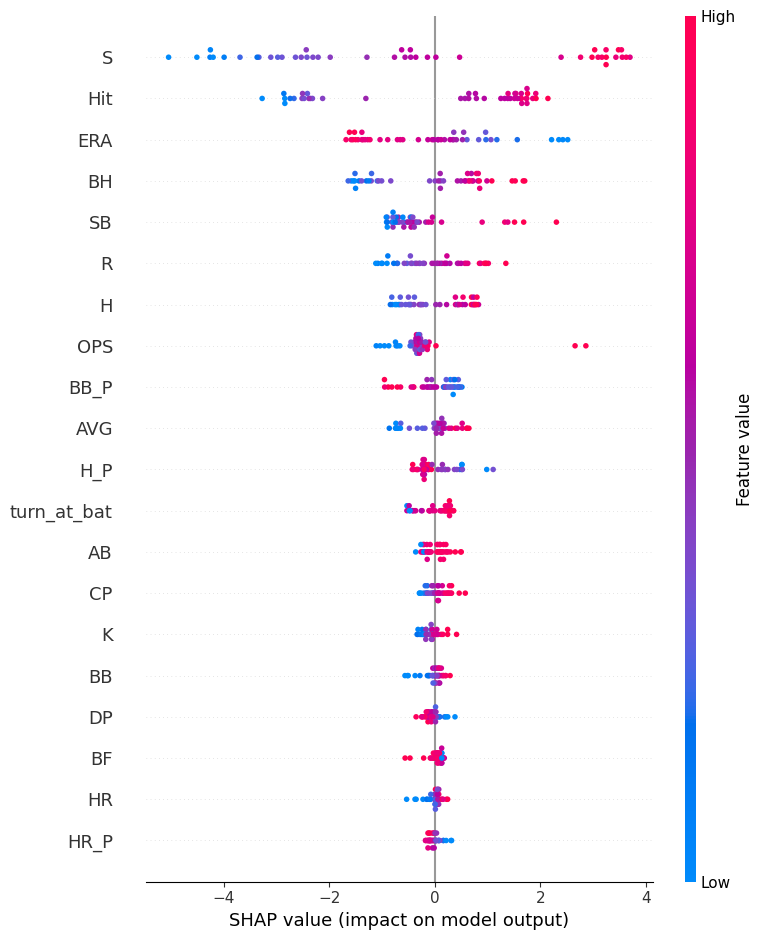

SVM SHAP (Sampled)


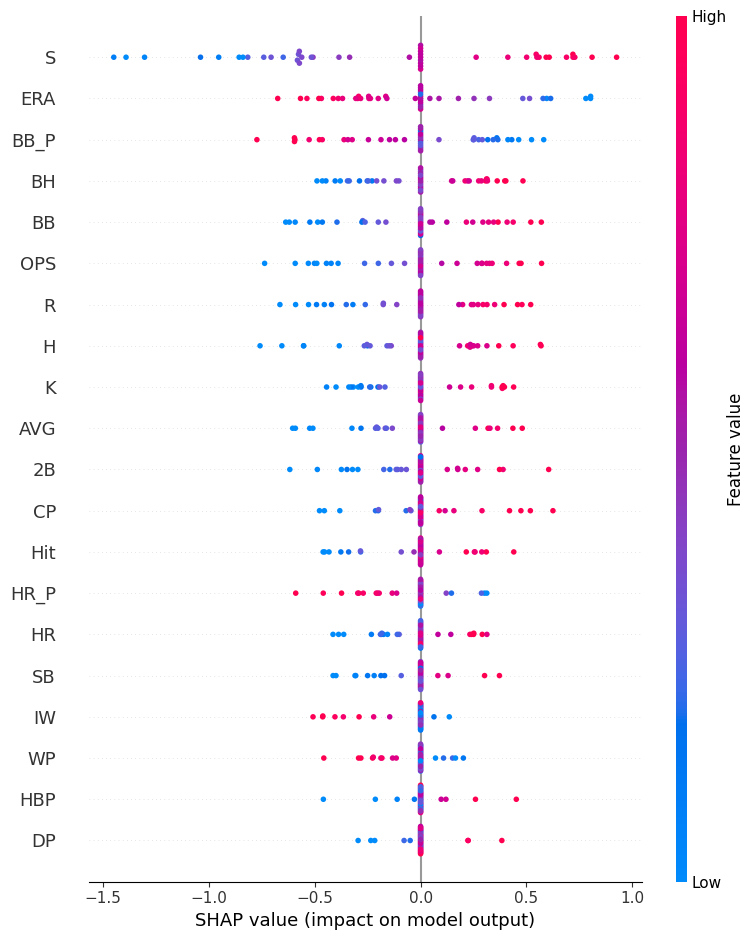

In [31]:

# プロット
print("XGBoost SHAP")
shap.summary_plot(shap_values_xgb, X_test)

print("Random Forest SHAP")
shap.summary_plot(shap_values_rf, X_test)

print("SVM SHAP (Sampled)")
shap.summary_plot(shap_values_svm, X_test_sample)